<a href="https://colab.research.google.com/github/sairaawahid/Data-Science-in-Python-Data-Prep-and-EDA/blob/main/Cleaning%20Data/Cleaning_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cleaning Data
**Methods/functions practiced for cleaning data, resolving missing, inconsistent, duplicated data and outliers, creating new columns:**
1.   `to_numeric()`
2.   Handle `NaN` values when using `str.replace()`
3.   `astype()`
4.   `value_counts()`
5.   `dropna()` `dropna(subset, inplace)`
6.    `isna()` `isna().sum()`
7.    `df[df.isna().any(axis=1)]`
8.    `fillna()`
9.   `loc[]`
10.   `np.where()`
11.   `map()`
12.   String methods: `str.strip()`, `str.lower()`, `str.replace()`
13.   `duplicated()`
14.   `duplicated(keep=False)`, `df[~df.duplicated()]`
15.   `drop_duplicates()`
16.   `reset_index(inplace=True)`
17.   `iloc[]`
18.   `hist(bins=);`
19.   `sns.histplot()`
20.   `sns.boxplot()`
21.   `np.mean()`, `np.std()`, `np.percentile()`
22.   List comprehension to loop through the data in a list
23.   Create new numeric columns
24.   Create new datetime columns: `dt.component`, `pd.to_timedelta()`
25.   `str[:]`, `str.split()`, `str.contains()`
26.   `to_list()`, `to_pickle()`

**Datasets:**
1.  Run Times.xlsx
2.  Student Grades.xlsx
3.  Groceries.xlsx

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import pandas as pd
import numpy as np

# **1. Data Types**

In [ ]:
run_times = pd.read_excel('/content/drive/MyDrive/Data Science in Pyhton by Maven Analytics/1. Data Prep & EDA/Data/Run Times.xlsx')
run_times

,Name,Run Time,Warm Up Time,Location,Run Date,Race Date,Rain,Fee
0,Alexis,9.2343,3.5,“school”,2023-04-15 12:00:00,2023-06-01,False,$0.00
1,Alexis,10.3842,3.5,School,2023-04-22 12:30:00,2023-06-01,True,$0.00
2,Alexis,8.1209,3 min,“the gym”,2023-05-10 15:00:00,2023-06-01,False,$2.50
3,David,7.2123,2.2,“school”,2023-05-01 15:15:00,2023-06-15,False,$0.00
4,David,6.8342,2,“gym”,2023-05-10 16:30:00,2023-06-15,False,$2.50


### a. Cleaning Data

Change data type of `Fee` to `float`

In [ ]:
run_times.Fee = pd.to_numeric(run_times.Fee.str.replace('$', ''))

In [ ]:
run_times.dtypes

,0
Name,object
Run Time,float64
Warm Up Time,object
Location,object
Run Date,datetime64[ns]
Race Date,datetime64[ns]
Rain,bool
Fee,float64


In [ ]:
run_times.head()

,Name,Run Time,Warm Up Time,Location,Run Date,Race Date,Rain,Fee
0,Alexis,9.2343,3.5,“school”,2023-04-15 12:00:00,2023-06-01,False,0.0
1,Alexis,10.3842,3.5,School,2023-04-22 12:30:00,2023-06-01,True,0.0
2,Alexis,8.1209,3 min,“the gym”,2023-05-10 15:00:00,2023-06-01,False,2.5
3,David,7.2123,2.2,“school”,2023-05-01 15:15:00,2023-06-15,False,0.0
4,David,6.8342,2,“gym”,2023-05-10 16:30:00,2023-06-15,False,2.5


Change data type of `Warm Up Time` to `float`

In [ ]:
pd.to_numeric(run_times['Warm Up Time'], errors='coerce')

# Call colnumn with [''] when there are spaces in column name

# Code works but required 3 value is replaced with NaN --> Try str.replace()

,Warm Up Time
0,3.5
1,3.5
2,NaN
3,2.2
4,2.0


In [ ]:
run_times['Warm Up Time'].str.replace(' min', '')
# All aother values are converted to NaN --> Try astype()

,Warm Up Time
0,NaN
1,NaN
2,3
3,NaN
4,NaN


In [ ]:
run_times['Warm Up Time'].astype('str').str.replace(' min', '')

,Warm Up Time
0,3.5
1,3.5
2,3
3,2.2
4,2


In [ ]:
run_times.dtypes

,0
Name,object
Run Time,float64
Warm Up Time,object
Location,object
Run Date,datetime64[ns]
Race Date,datetime64[ns]
Rain,bool
Fee,float64


In [ ]:
run_times.Rain = run_times.Rain.astype('int')

In [ ]:
run_times.info()
run_times.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Name          5 non-null      object        
 1   Run Time      5 non-null      float64       
 2   Warm Up Time  5 non-null      object        
 3   Location      5 non-null      object        
 4   Run Date      5 non-null      datetime64[ns]
 5   Race Date     5 non-null      datetime64[ns]
 6   Rain          5 non-null      int64         
 7   Fee           5 non-null      float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(3)
memory usage: 452.0+ bytes


,Name,Run Time,Warm Up Time,Location,Run Date,Race Date,Rain,Fee
0,Alexis,9.2343,3.5,“school”,2023-04-15 12:00:00,2023-06-01,0,0.0
1,Alexis,10.3842,3.5,School,2023-04-22 12:30:00,2023-06-01,1,0.0
2,Alexis,8.1209,3 min,“the gym”,2023-05-10 15:00:00,2023-06-01,0,2.5
3,David,7.2123,2.2,“school”,2023-05-01 15:15:00,2023-06-15,0,0.0
4,David,6.8342,2,“gym”,2023-05-10 16:30:00,2023-06-15,0,2.5


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

# **2. Missing Data**

### a. Find Missing Data

In [ ]:
# Missing data representations in Python

"""
np.NaN
pd.NA
None
"""

'\nnp.NaN\npd.NA\nNone\n'

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Data Science in Pyhton by Maven Analytics/1. Data Prep & EDA/Data/Student Grades.xlsx')
df

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0
...,...,...,...,...
81,NaN,NaN,NaN,NaN
82,Bennett,NaN,NaN,NaN
83,NaN,EDA,Junior,84.0
84,Gavin,EDA,Senior,NaN


In [ ]:
# Quickly explore the DataFrame
df.info()

# 86 entries but Non-Null Count != 86

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Student  84 non-null     object 
 1   Class    83 non-null     object 
 2   Year     80 non-null     object 
 3   Grade    82 non-null     float64
dtypes: float64(1), object(3)
memory usage: 2.8+ KB


In [ ]:
df.value_counts()
# shows all the unique rows in a df with df.value_counts(dropna=True)
# Try df.value_counts(dropna=False)

,,,,count
Student,Class,Year,Grade,
Isaac,Intro to SQL,Sophomore,96.0,3
Abigail,Intro to Python,Freshman,89.0,1
Aaron,EDA,Junior,85.0,1
Alexander,Intro to Python,Freshman,85.0,1
Amelia,Intro to SQL,Sophomore,90.0,1
...,...,...,...,...
Sofia,Intro to SQL,Sophomore,79.0,1
Sophia,Freshman Seminar,Freshman,87.0,1
Victoria,Exploratory Data Analysis,Junior,90.0,1


### b. Removing Missing Data

In [ ]:
# Take a look at the unique values (including NaN) in the Year column
df.value_counts(dropna=False)

,,,,count
Student,Class,Year,Grade,
Isaac,Intro to SQL,Sophomore,96.0,3
Aaron,EDA,Junior,85.0,1
Aiden,Intro to Python,Freshman,86.0,1
Abigail,Intro to Python,Freshman,89.0,1
Amelia,Intro to SQL,Sophomore,90.0,1
...,...,...,...,...
William,Freshman Seminar,NaN,89.0,1
Wyatt,Intro to SQL,Sophomore,45.0,1
Zoey,EDA,Junior,91.0,1


In [ ]:
# Try df.value_counts(dropna=False) on a single column
df.Year.value_counts()

,count
Year,
Freshman,35
Sophomore,24
Junior,20
Senior,1


In [ ]:
df.Year.value_counts(dropna=False)

,count
Year,
Freshman,35
Sophomore,24
Junior,20
NaN,6
Senior,1


In [ ]:
# All cells that have a NaN value
df.isna()

,Student,Class,Year,Grade
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
81,True,True,True,True
82,False,True,True,True
83,True,False,False,False
84,False,False,False,True


In [ ]:
# Finding total missing value in each column
# Return the number of NaNs in each column

df.isna().sum()

,0
Student,2
Class,3
Year,6
Grade,4


In [ ]:
# Rows with any NaNs
# See if there are missing values in each row
df.isna().any(axis=1)

# .any(axis=1) gives True(NaN)/False(no NaN) for each row


,0
0,False
1,False
2,False
3,False
4,False
...,...
81,True
82,True
83,True
84,True


In [ ]:
# Finding missing value in any row
df[df.isna().any(axis=1)]

# only shows rows with missing values

,Student,Class,Year,Grade
7,Jacob,Freshman Seminar,NaN,88.0
8,William,Freshman Seminar,NaN,89.0
9,Ethan,Freshman Seminar,NaN,86.0
62,Landon,Exploratory Data Analysis,Junior,NaN
81,NaN,NaN,NaN,NaN
82,Bennett,NaN,NaN,NaN
83,NaN,EDA,Junior,84.0
84,Gavin,EDA,Senior,NaN
85,Calvin,NaN,NaN,100.0


In [ ]:
# Drop rows that don't have a student or class name

# All rows that has NaN in 'Student' or 'Class' columns
df[df.isna().any(axis=1)].dropna(subset=['Student', 'Class'])

,Student,Class,Year,Grade
7,Jacob,Freshman Seminar,NaN,88.0
8,William,Freshman Seminar,NaN,89.0
9,Ethan,Freshman Seminar,NaN,86.0
62,Landon,Exploratory Data Analysis,Junior,NaN
84,Gavin,EDA,Senior,NaN


Using `.dropna()` or `.notna()` to remove rows with NaN values does not make permanent changes to a df.
So, either:
- Save it as new df or same one, or
- Use argument `inplace=True`

`inplace=True` is used to apply changes directly to the DataFrame you are working on, rather than returning a new object.

In [ ]:
# Apply to entire DataFrame
# Save it as new df or same one

df = df.dropna(subset=['Student', 'Class'])
df

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0
...,...,...,...,...
77,Aaron,EDA,Junior,85.0
78,Charles,EDA,Junior,93.0
79,Connor,EDA,Junior,91.0
80,Riley,EDA,Junior,87.0


In [ ]:
# Use inplace=True

df.dropna(subset=['Student', 'Class'], inplace=True)
df

/tmp/ipykernel_1092/3959930459.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['Student', 'Class'], inplace=True)


,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0
...,...,...,...,...
77,Aaron,EDA,Junior,85.0
78,Charles,EDA,Junior,93.0
79,Connor,EDA,Junior,91.0
80,Riley,EDA,Junior,87.0


### c. Imputing Missing Data

In [ ]:
# Check the rows with missing grades
df[df.Grade.isna()]

,Student,Class,Year,Grade
62,Landon,Exploratory Data Analysis,Junior,NaN
84,Gavin,EDA,Senior,NaN


Fill above missing grades with mean grade

In [ ]:
df.Grade.mean()

np.float64(85.55)

In [ ]:
#Impute the NaN grades
df.Grade.fillna(df.Grade.mean(), inplace=True)
df.Grade

/tmp/ipykernel_1092/2015825990.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Grade.fillna(df.Grade.mean(), inplace=True)
/tmp/ipykernel_1092/2015825990.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.Grade.fillna(df.Grade.mean(), inplace=True)


,Grade
0,86.00
1,86.00
2,86.00
3,87.00
4,90.00
...,...
77,85.00
78,93.00
79,91.00
80,87.00


### d. Resolving Missing Data
An alternative of imputing missing data with `.loc[]` accessor to fill in a specific missing data.


In [ ]:
# Check the rows with NaNs
df[df.isna().any(axis=1)]

,Student,Class,Year,Grade
7,Jacob,Freshman Seminar,NaN,88.0
8,William,Freshman Seminar,NaN,89.0
9,Ethan,Freshman Seminar,NaN,86.0


*If you're domain expert or just by looking at data, you may know what is missing value should actually be.*


In [ ]:
# Look at all Freshman Seminar students
df[df.Class == 'Freshman Seminar']

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0
5,Mason,Freshman Seminar,Freshman,90.0
6,Isabella,Freshman Seminar,Freshman,90.0
7,Jacob,Freshman Seminar,NaN,88.0
8,William,Freshman Seminar,NaN,89.0
9,Ethan,Freshman Seminar,NaN,86.0


In [ ]:
# Update a specific value
df.loc[7, 'Year'] = 'Freshman'

"""
Upon running the above cell, row no. 7 will be Year = Freshman
But, instead of updating each value one by one, do it all
together using np.where().
"""

'\nUpon running the above cell, row no. 7 will be Year = Freshman\nBut, instead of updating each value one by one, do it all\ntogether using np.where().\n'

In [ ]:
# Update multiple values using np.where()
import numpy as np

df.Year = np.where(df.Year.isna(), 'Freshman', df.Year)
df.head(11)

/tmp/ipykernel_1092/1482095315.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.Year = np.where(df.Year.isna(), 'Freshman', df.Year)


,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0
5,Mason,Freshman Seminar,Freshman,90.0
6,Isabella,Freshman Seminar,Freshman,90.0
7,Jacob,Freshman Seminar,Freshman,88.0
8,William,Freshman Seminar,Freshman,89.0
9,Ethan,Freshman Seminar,Freshman,86.0


In [ ]:
# Check the rows with NaNs
df[df.isna().any(axis=1)]

,Student,Class,Year,Grade


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

## 3. Inconsistent Text and Typos

### a. Find inconsistent text and typos

In [ ]:
# Find inconsistencies in categorical columns
df.Class.value_counts()

,count
Class,
Intro to Python,25
Intro to SQL,20
Freshman Seminar,12
Exploratory Data Analysis,12
EDA,12
Python,1


In [ ]:
# Look at Exploratory Data Analysis students vs EDA students
df[df.Class.isin(['Exploratory Data Analysis', 'EDA'])]

,Student,Class,Year,Grade
58,Evelyn,Exploratory Data Analysis,Sophomore,89.00
59,Jack,Exploratory Data Analysis,Sophomore,84.00
60,Ella,Exploratory Data Analysis,Sophomore,200.00
61,Chloe,Exploratory Data Analysis,Sophomore,87.00
62,Landon,Exploratory Data Analysis,Junior,85.55
63,Christian,Exploratory Data Analysis,Junior,77.00
64,Jordan,Exploratory Data Analysis,Junior,83.00
65,Jonathan,Exploratory Data Analysis,Junior,82.00
66,Levi,Exploratory Data Analysis,Junior,91.00
67,Victoria,Exploratory Data Analysis,Junior,90.00


In [ ]:
# Look at Intro to Python students vs Python students
df[df.Class.isin(['Intro to Python', 'Python'])]

,Student,Class,Year,Grade
12,Alexander,Intro to Python,Freshman,85.0
13,Logan,Intro to Python,Freshman,85.0
14,James,Intro to Python,Freshman,82.0
15,Daniel,Intro to Python,Freshman,85.0
16,Elijah,Intro to Python,Freshman,85.0
17,Benjamin,Intro to Python,Freshman,81.0
18,Mia,Intro to Python,Freshman,80.0
19,Mia,Python,Freshman,80.0
20,Jayden,Intro to Python,Freshman,82.0
21,Aiden,Intro to Python,Freshman,86.0


In [ ]:
df.Year.value_counts()

,count
Year,
Freshman,38
Sophomore,24
Junior,19
Senior,1


In [ ]:
# Find inconsistencies in numerical columns
df.Grade.describe()

,Grade
count,82.000000
mean,85.550000
std,15.443965
min,45.000000
25%,81.000000
50%,85.275000
75%,89.750000
max,200.000000


*In above decsriptive stats, min-max range is unrealistic.*

In [ ]:
# Find which row has grade above 100
df[df.Grade > 100]

,Student,Class,Year,Grade
60,Ella,Exploratory Data Analysis,Sophomore,200.0


### b. Handle inconsistent text and typos

In [ ]:
# Remember our DataFrame
df.head()

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0


In [ ]:
# Check the unique class values
df.Class.value_counts()

,count
Class,
Intro to Python,25
Intro to SQL,20
Freshman Seminar,12
Exploratory Data Analysis,12
EDA,12
Python,1


In [ ]:
# Replace EDA with Exploratory Data Analysis
np.where(df.Class == 'EDA', 'Exploratory Data Analysis', df.Class)

array(['Freshman Seminar', 'Freshman Seminar', 'Freshman Seminar',
       'Freshman Seminar', 'Freshman Seminar', 'Freshman Seminar',
       'Freshman Seminar', 'Freshman Seminar', 'Freshman Seminar',
       'Freshman Seminar', 'Freshman Seminar', 'Freshman Seminar',
       'Intro to Python', 'Intro to Python', 'Intro to Python',
       'Intro to Python', 'Intro to Python', 'Intro to Python',
       'Intro to Python', 'Python', 'Intro to Python', 'Intro to Python',
       'Intro to Python', 'Intro to Python', 'Intro to Python',
       'Intro to Python', 'Intro to Python', 'Intro to Python',
       'Intro to Python', 'Intro to Python', 'Intro to Python',
       'Intro to Python', 'Intro to Python', 'Intro to Python',
       'Intro to Python', 'Intro to Python', 'Intro to Python',
       'Intro to Python', 'Intro to SQL', 'Intro to SQL', 'Intro to SQL',
       'Intro to SQL', 'Intro to SQL', 'Intro to SQL', 'Intro to SQL',
       'Intro to SQL', 'Intro to SQL', 'Intro to SQL', 'Intro to 

In [ ]:
# np.where doesn't change the DataFrame. So save it to original df.
df.Class = np.where(df.Class == 'EDA', 'Exploratory Data Analysis', df.Class)
df.Class.value_counts()

/tmp/ipykernel_1092/3219665048.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.Class = np.where(df.Class == 'EDA', 'Exploratory Data Analysis', df.Class)


,count
Class,
Intro to Python,25
Exploratory Data Analysis,24
Intro to SQL,20
Freshman Seminar,12
Python,1


In [ ]:
# Replace Python with Intro to Python
df.Class = np.where(df.Class == 'Python', 'Intro to Python', df.Class)
df.Class.value_counts()

/tmp/ipykernel_1092/406784448.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.Class = np.where(df.Class == 'Python', 'Intro to Python', df.Class)


,count
Class,
Intro to Python,26
Exploratory Data Analysis,24
Intro to SQL,20
Freshman Seminar,12


In [ ]:
# Replace the 200 value with 100
df.Grade = np.where(df.Grade > 100, 100, df.Grade)
df.Grade

/tmp/ipykernel_1092/1288795220.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.Grade = np.where(df.Grade > 100, 100, df.Grade)


,Grade
0,86.00
1,86.00
2,86.00
3,87.00
4,90.00
...,...
77,85.00
78,93.00
79,91.00
80,87.00


In [ ]:
df.Grade.describe()

,Grade
count,82.000000
mean,84.330488
std,8.824663
min,45.000000
25%,81.000000
50%,85.275000
75%,89.750000
max,100.000000


### c. Map values

In [ ]:
df.Class.value_counts()

,count
Class,
Intro to Python,26
Exploratory Data Analysis,24
Intro to SQL,20
Freshman Seminar,12


In [ ]:
class_mapping = {'EDA' : 'Exploratory Data Analysis',
                 'Exploratory Data Analysis' : 'Exploratory Data Analysis',
                 'Python' : 'Intro to Python',
                 'Intro to Python' : 'Intro to Python',
                 'Intro to SQL' : 'Intro to SQL',
                 'Freshman Seminar' : 'Freshman Seminar'}

In [ ]:
df.Class = df.Class.map(class_mapping)
df.Class.value_counts()


/tmp/ipykernel_1092/3232829273.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.Class = df.Class.map(class_mapping)


,count
Class,
Intro to Python,26
Exploratory Data Analysis,24
Intro to SQL,20
Freshman Seminar,12


### d. Clean Text Data

In [ ]:
run_times

,Name,Run Time,Warm Up Time,Location,Run Date,Race Date,Rain,Fee
0,Alexis,9.2343,3.5,“school”,2023-04-15 12:00:00,2023-06-01,0,0.0
1,Alexis,10.3842,3.5,School,2023-04-22 12:30:00,2023-06-01,1,0.0
2,Alexis,8.1209,3 min,“the gym”,2023-05-10 15:00:00,2023-06-01,0,2.5
3,David,7.2123,2.2,“school”,2023-05-01 15:15:00,2023-06-15,0,0.0
4,David,6.8342,2,“gym”,2023-05-10 16:30:00,2023-06-15,0,2.5


Clean `Location` column by removing `'the'` and `""`, make all characters lowercase.

In [ ]:
run_times.Location.str.strip('""').str.lower().str.replace('the', '')

,Location
0,“school”
1,school
2,“ gym”
3,“school”
4,“gym”


Nothing is stripped because `" "` is different than `“ ”` used in data.
Copy it from the df and paste in `str.strip()`.

In [ ]:
run_times.Location.str.strip('“”').str.lower().str.replace('the', '')

,Location
0,school
1,school
2,gym
3,school
4,gym


In [ ]:
# Save to original df
run_times.Location = run_times.Location.str.strip('“”').str.lower().str.replace('the', '')

In [ ]:
run_times

,Name,Run Time,Warm Up Time,Location,Run Date,Race Date,Rain,Fee
0,Alexis,9.2343,3.5,school,2023-04-15 12:00:00,2023-06-01,0,0.0
1,Alexis,10.3842,3.5,school,2023-04-22 12:30:00,2023-06-01,1,0.0
2,Alexis,8.1209,3 min,gym,2023-05-10 15:00:00,2023-06-01,0,2.5
3,David,7.2123,2.2,school,2023-05-01 15:15:00,2023-06-15,0,0.0
4,David,6.8342,2,gym,2023-05-10 16:30:00,2023-06-15,0,2.5


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

## 4. Duplicate Rows

### a. Find duplicate rows

In [ ]:
# Remember our DataFrame
df.head()

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
77,False
78,False
79,False
80,False


In [ ]:
# View the duplicate rows
df[df.duplicated()]

,Student,Class,Year,Grade
19,Mia,Intro to Python,Freshman,80.0
43,Isaac,Intro to SQL,Sophomore,96.0
44,Isaac,Intro to SQL,Sophomore,96.0


In [ ]:
# View all the duplicates
df[df.duplicated(keep=False)]

# (keep=False) argument shows both or all rows of duplicate data,
# not just first or last as in (keep=first) or (keep=last)

,Student,Class,Year,Grade
18,Mia,Intro to Python,Freshman,80.0
19,Mia,Intro to Python,Freshman,80.0
42,Isaac,Intro to SQL,Sophomore,96.0
43,Isaac,Intro to SQL,Sophomore,96.0
44,Isaac,Intro to SQL,Sophomore,96.0


In [ ]:
df[df.duplicated(keep='first')]


,Student,Class,Year,Grade
19,Mia,Intro to Python,Freshman,80.0
43,Isaac,Intro to SQL,Sophomore,96.0
44,Isaac,Intro to SQL,Sophomore,96.0


In [ ]:
df[df.duplicated(keep='last')]


,Student,Class,Year,Grade
18,Mia,Intro to Python,Freshman,80.0
42,Isaac,Intro to SQL,Sophomore,96.0
43,Isaac,Intro to SQL,Sophomore,96.0


### b. Handle duplicate rows

In [ ]:
# Remove the duplicate values
df.drop_duplicates()

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.00
1,Olivia,Freshman Seminar,Freshman,86.00
2,Noah,Freshman Seminar,Freshman,86.00
3,Sophia,Freshman Seminar,Freshman,87.00
4,Liam,Freshman Seminar,Freshman,90.00
...,...,...,...,...
77,Aaron,Exploratory Data Analysis,Junior,85.00
78,Charles,Exploratory Data Analysis,Junior,93.00
79,Connor,Exploratory Data Analysis,Junior,91.00
80,Riley,Exploratory Data Analysis,Junior,87.00


In [ ]:
# Save the results
df.drop_duplicates(inplace=True)
df

"""
An alternative to (inplace=True), save df.drop_duplicates() back to df: df = df.drop_duplicates()
or
Keep non-duplicated rows by doing opposite of df[df.duplicated()]: df[~df.duplicated()]
"""

/tmp/ipykernel_1092/3164457070.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


'\nAn alternative to (inplace=True), save df.drop_duplicates() back to df: df = df.drop_duplicates()\nor\nKeep non-duplicated rows by doing opposite of df[df.duplicated()]: df[~df.duplicated()]\n'

### c. Reset index after `drop_duplicate()`

In [ ]:
df.iloc[40:45, :]
# Index no. is skipping

,Student,Class,Year,Grade
41,Charlotte,Intro to SQL,Sophomore,92.0
42,Isaac,Intro to SQL,Sophomore,96.0
45,Harper,Intro to SQL,Sophomore,93.0
46,Ryan,Intro to SQL,Sophomore,76.0
47,Sofia,Intro to SQL,Sophomore,79.0


In [ ]:
df.reset_index()
# In output, new column of index data is created.

,index,Student,Class,Year,Grade
0,0,Emma,Freshman Seminar,Freshman,86.00
1,1,Olivia,Freshman Seminar,Freshman,86.00
2,2,Noah,Freshman Seminar,Freshman,86.00
3,3,Sophia,Freshman Seminar,Freshman,87.00
4,4,Liam,Freshman Seminar,Freshman,90.00
...,...,...,...,...,...
74,77,Aaron,Exploratory Data Analysis,Junior,85.00
75,78,Charles,Exploratory Data Analysis,Junior,93.00
76,79,Connor,Exploratory Data Analysis,Junior,91.00
77,80,Riley,Exploratory Data Analysis,Junior,87.00


In [ ]:
# Remove new column of index data and save the result
df.reset_index(drop=True, inplace=True)
df.iloc[40:45, :]


,Student,Class,Year,Grade
40,Charlotte,Intro to SQL,Sophomore,92.0
41,Isaac,Intro to SQL,Sophomore,96.0
42,Harper,Intro to SQL,Sophomore,93.0
43,Ryan,Intro to SQL,Sophomore,76.0
44,Sofia,Intro to SQL,Sophomore,79.0


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

## 5. Outliers

### a. Find outliers

#### i. Histograms

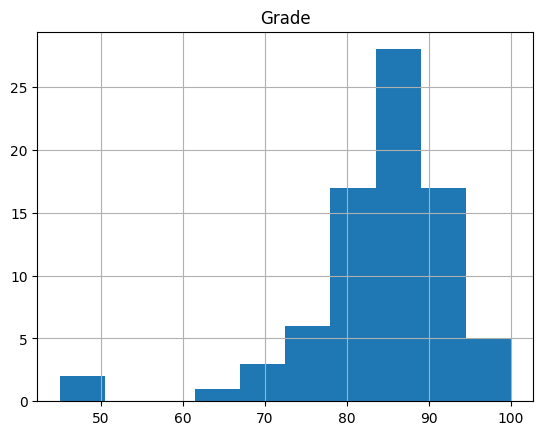

In [ ]:
# Basic histogram
df.hist();

In [ ]:
# Difference between min and max grades
df.Grade.max() - df.Grade.min()

55.0

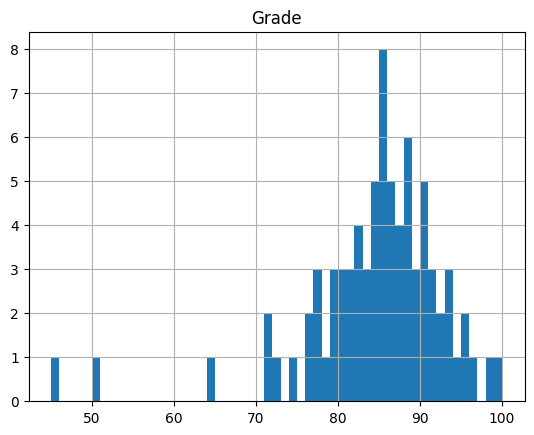

In [ ]:
# Change the bin size to show each grade individually
df.hist(bins=55);

In [ ]:
# Histogram using seaborn
import seaborn as sns

<Axes: ylabel='Count'>

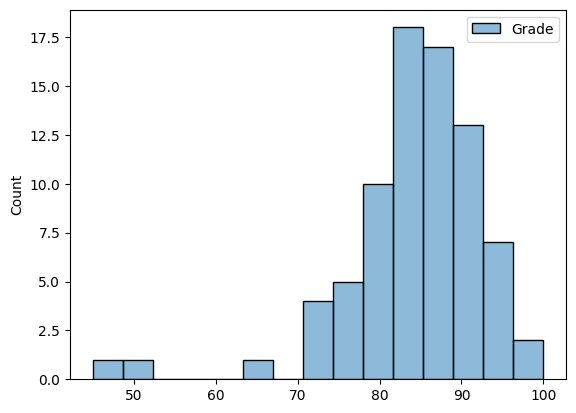

In [ ]:
sns.histplot(df)
# sns.histplot(df); to remove axes info above visual output

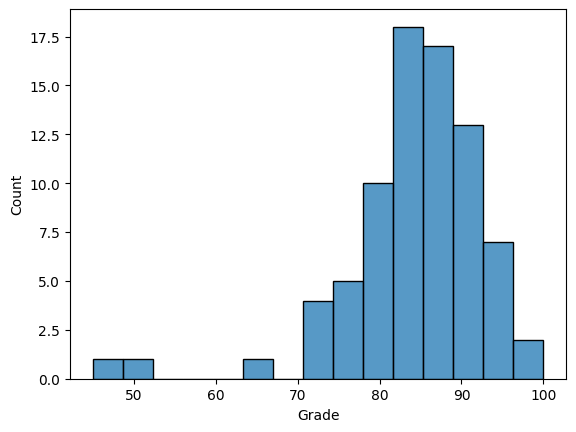

In [ ]:
# Look specifically at the grade column
sns.histplot(df.Grade);

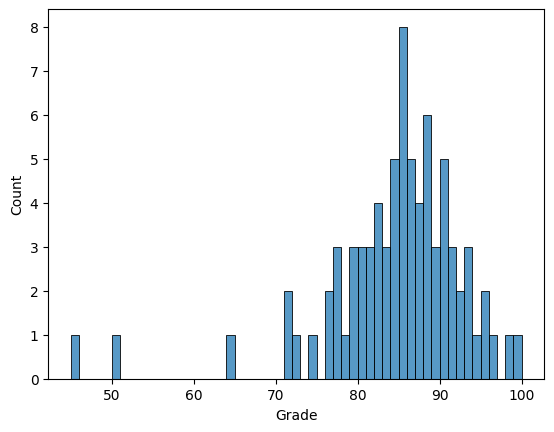

In [ ]:
# Specify that each bin should only include 1 grade
sns.histplot(df.Grade, binwidth=1);

#### ii. Box plots

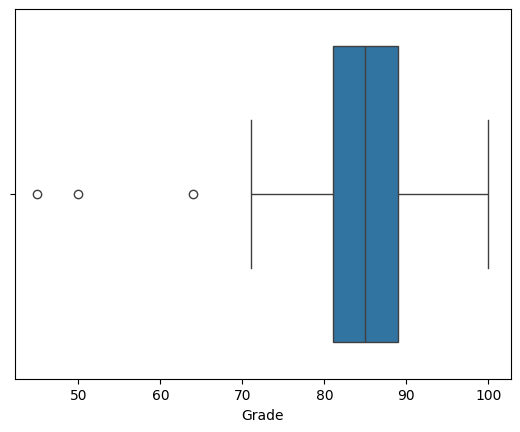

In [ ]:
sns.boxplot(x=df.Grade);

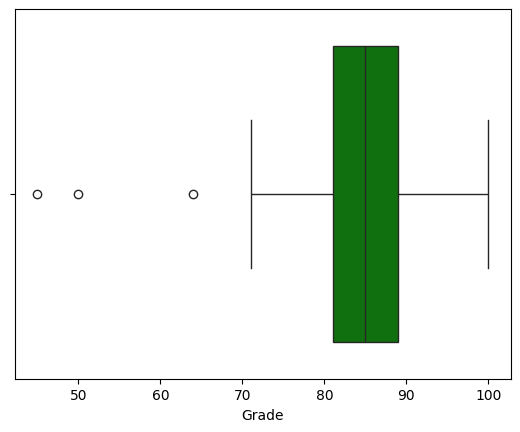

In [ ]:
sns.boxplot(x=df.Grade, color='green');

In [ ]:
# Identify the box plot outliers

# Calculate the quartiles
q25, q50, q75 = np.percentile(df.Grade, [25, 50, 75])

# Calculate IQR
iqr = q75 - q25

# Calculate lower bound(min) and upper bound(max)
min_grade = q25 - (1.5*iqr)
max_grade = q75 + (1.5*iqr)

# Show calculations
print(min_grade, q25, q50, q75, max_grade)

69.0 81.0 85.0 89.0 101.0


In [ ]:
# Identify the outliers
df[df.Grade < 69.0]

,Student,Class,Year,Grade
36,John,Intro to Python,Freshman,50.0
53,Wyatt,Intro to SQL,Sophomore,45.0
66,Jaxon,Exploratory Data Analysis,Junior,64.0


#### iii. Standard deviation

In [ ]:
# Calculate the mean and standard deviation

mean = np.mean(df.Grade)
sd = np.std(df.Grade)

# Show mean and standard deviation
print(mean, sd)

84.08987341772152 8.723725033779411


In [ ]:
# Identify points that are more than 3 standard deviations away
[grade for grade in df.Grade if (grade < (mean - 3*sd)) or (grade > (mean + 3*sd))]

[50.0, 45.0]

In [ ]:
# Identify points that are more than 2 standard deviations away
[grade for grade in df.Grade if (grade < (mean - 2*sd)) or (grade > (mean + 2*sd))]

[50.0, 45.0, 64.0]

In [ ]:
# Identify points that are more than 4 standard deviations away
[grade for grade in df.Grade if (grade < (mean - 4*sd)) or (grade > (mean + 4*sd))]

[45.0]

In [ ]:
# View all ordered grades

df.Grade.sort_values()

,Grade
53,45.0
36,50.0
66,64.0
35,71.0
39,71.0
...,...
67,95.0
32,95.0
41,96.0
49,98.0


### b. Handle Outliers

#### i. Remove an entire row or column

In [ ]:
df.shape

(79, 4)

In [ ]:
# Locate the outliers
df[df.Grade < 60]

,Student,Class,Year,Grade
36,John,Intro to Python,Freshman,50.0
53,Wyatt,Intro to SQL,Sophomore,45.0


In [ ]:
# Option 1: Drop the two rows with outliers
df.drop([36, 53])

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.00
1,Olivia,Freshman Seminar,Freshman,86.00
2,Noah,Freshman Seminar,Freshman,86.00
3,Sophia,Freshman Seminar,Freshman,87.00
4,Liam,Freshman Seminar,Freshman,90.00
...,...,...,...,...
74,Aaron,Exploratory Data Analysis,Junior,85.00
75,Charles,Exploratory Data Analysis,Junior,93.00
76,Connor,Exploratory Data Analysis,Junior,91.00
77,Riley,Exploratory Data Analysis,Junior,87.00


In [ ]:
# Option 2: Filter the data to exclude the outliers using logic. This is the opposite of the result above.
df[df.Grade >= 60]

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.00
1,Olivia,Freshman Seminar,Freshman,86.00
2,Noah,Freshman Seminar,Freshman,86.00
3,Sophia,Freshman Seminar,Freshman,87.00
4,Liam,Freshman Seminar,Freshman,90.00
...,...,...,...,...
74,Aaron,Exploratory Data Analysis,Junior,85.00
75,Charles,Exploratory Data Analysis,Junior,93.00
76,Connor,Exploratory Data Analysis,Junior,91.00
77,Riley,Exploratory Data Analysis,Junior,87.00


#### ii. Impute the data

In [ ]:
# Identify the outliers
df[df.Grade < 60]

,Student,Class,Year,Grade
36,John,Intro to Python,Freshman,50.0
53,Wyatt,Intro to SQL,Sophomore,45.0


In [ ]:
# Minimum of the non-outliers
min_grade = df[df.Grade >= 60].Grade.min()
min_grade

64.0

In [ ]:
# Update the outlier values with the minimum grade
df.Grade = np.where(df.Grade < 60, min_grade, df.Grade)
df.Grade

/tmp/ipykernel_1092/1180872971.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.Grade = np.where(df.Grade < 60, min_grade, df.Grade)


,Grade
0,86.00
1,86.00
2,86.00
3,87.00
4,90.00
...,...
74,85.00
75,93.00
76,91.00
77,87.00


In [ ]:
# Confirm the updated values
df[df.Grade < 60]

,Student,Class,Year,Grade


In [ ]:
# Confirm the updated values
df.loc[[36, 53]]

,Student,Class,Year,Grade
36,John,Intro to Python,Freshman,64.0
53,Wyatt,Intro to SQL,Sophomore,64.0


#### iii. Resolve outliers based on domain expertise

In [ ]:
# See John's information
df[df.Student == 'John']

,Student,Class,Year,Grade
36,John,Intro to Python,Freshman,64.0


In [ ]:
# His last test wasn't logged and he should have an 74
df.loc[36, 'Grade'] = 74

In [ ]:
# Confirm the updated value
df[df.Student == 'John']

,Student,Class,Year,Grade
36,John,Intro to Python,Freshman,74.0


### c. Review Clean Data

In [ ]:
# No more missing data
df[df.isna().any(axis=1)]

,Student,Class,Year,Grade


In [ ]:
# No more inconsistent data
df.Class.value_counts()

,count
Class,
Intro to Python,25
Exploratory Data Analysis,24
Intro to SQL,18
Freshman Seminar,12


In [ ]:
# No more duplicate data
df[df.duplicated()]

,Student,Class,Year,Grade


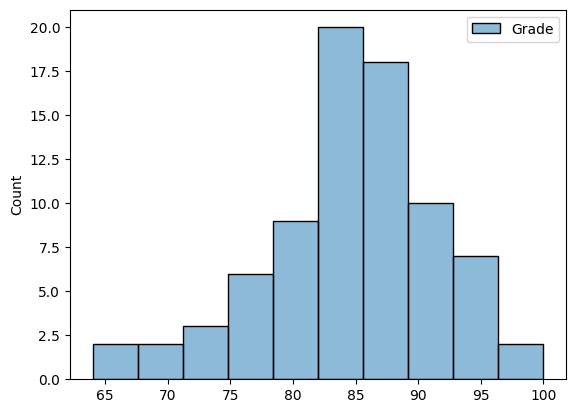

In [ ]:
# No more outliers
sns.histplot(df);

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

## 6. Create New Columns From Numeric Columns

In [29]:
# Read in the data
groceries = pd.read_excel('/content/drive/MyDrive/Data Science in Pyhton by Maven Analytics/1. Data Prep & EDA/Data/Groceries.xlsx')
groceries.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15


### a. Basic math calculations

In [30]:
# Increase price by 5%, round to two decimal places and save as a new column
groceries['New_Price'] = round(groceries.Price_Dollars * 1.05, 2)
groceries.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New_Price
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19


### b. Calculate percent of inventory

In [31]:
# Total inventory
groceries['Total Inventory'] = groceries.Inventory.sum()
groceries.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New_Price,Total Inventory
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857


In [32]:
# Percent of inventory
groceries['Percent Inventory'] = round(groceries.Inventory / groceries['Total Inventory'] * 100, 2)
groceries.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New_Price,Total Inventory,Percent Inventory
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857,7.19
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857,10.29
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857,4.12
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857,1.03
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857,3.05


### c. Flag low inventory items

In [33]:
groceries['Low Inventory'] = np.where(groceries.Inventory < 50, 'Low inventory', '')

# See only low inventory items
groceries[groceries['Low Inventory'] == 'Low inventory']

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New_Price,Total Inventory,Percent Inventory,Low Inventory
15,P100025,Produce: Dairy,Milk (Soy),4.49,32,2023-06-13 08:37:00,2023-06-17,4.71,4857,0.66,Low inventory
17,P100027,Pantry: Snacks,Apple Sauce - organic,1.50,27,2023-06-10 12:02:00,2023-06-24,1.58,4857,0.56,Low inventory
20,P100030,Pantry: Snacks,Raisins,2.99,5,2023-06-10 12:38:00,2023-06-24,3.14,4857,0.10,Low inventory


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

## 7. Create New Columns From DateTime Columns

In [34]:
# Extract the time from 'Last_Updated'
groceries['Last_Updated_Time'] = groceries.Last_Updated.dt.time
groceries.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New_Price,Total Inventory,Percent Inventory,Low Inventory,Last_Updated_Time
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857,7.19,,15:35:00
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857,10.29,,18:30:00
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857,4.12,,17:22:00
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857,1.03,,16:29:00
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857,3.05,,18:10:00


In [35]:
# Extract the day of the week from 'Next_Scheduled_Shipment'
groceries['Shipment_Date_DOW'] = groceries['Next_Scheduled_Shipment'].dt.dayofweek
groceries.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New_Price,Total Inventory,Percent Inventory,Low Inventory,Last_Updated_Time,Shipment_Date_DOW
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857,7.19,,15:35:00,3
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857,10.29,,18:30:00,3
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857,4.12,,17:22:00,3
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857,1.03,,16:29:00,3
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857,3.05,,18:10:00,3


In [36]:
# Change numeric day of week in 'Shipment_Date_DOW' to names

# day of week mapping
dow_mapping = {0: 'Monday',
               1: 'Tuesday',
               2: 'Wednesday',
               3: 'Thursday',
               4: 'Friday',
               5: 'Saturday',
               6: 'Sunday'}

groceries['Shipment_Date_DOW'] = groceries['Shipment_Date_DOW'].map(dow_mapping)
groceries.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New_Price,Total Inventory,Percent Inventory,Low Inventory,Last_Updated_Time,Shipment_Date_DOW
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857,7.19,,15:35:00,Thursday
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857,10.29,,18:30:00,Thursday
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857,4.12,,17:22:00,Thursday
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857,1.03,,16:29:00,Thursday
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857,3.05,,18:10:00,Thursday


In [37]:
# Add 1 day to shipment date
groceries['Next_Scheduled_Shipment'] + pd.to_timedelta(1, 'D')

,Next_Scheduled_Shipment
0,2023-06-16
1,2023-06-16
2,2023-06-16
3,2023-06-16
4,2023-06-16
5,2023-06-16
6,2023-06-16
7,2023-06-16
8,2023-06-16
9,2023-06-16


In [38]:
# Only add 1 day to fruit delivery
groceries['New_Shipment_Date'] = np.where(groceries.Category == 'Produce: Fruit',
         groceries.Next_Scheduled_Shipment + pd.to_timedelta(1, 'D'),
         groceries.Next_Scheduled_Shipment)
groceries.head(10)

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New_Price,Total Inventory,Percent Inventory,Low Inventory,Last_Updated_Time,Shipment_Date_DOW,New_Shipment_Date
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857,7.19,,15:35:00,Thursday,2023-06-16
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857,10.29,,18:30:00,Thursday,2023-06-16
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857,4.12,,17:22:00,Thursday,2023-06-16
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857,1.03,,16:29:00,Thursday,2023-06-16
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857,3.05,,18:10:00,Thursday,2023-06-16
5,P100015,Produce: Fruit,Watermelon,5.99,99,2023-06-12 19:15:00,2023-06-15,6.29,4857,2.04,,19:15:00,Thursday,2023-06-16
6,P100016,Produce: Vegetable,Cabbage,1.78,78,2023-06-12 19:25:00,2023-06-15,1.87,4857,1.61,,19:25:00,Thursday,2023-06-15
7,P100017,Produce: Vegetable,Carrots,2.00,200,2023-06-12 18:05:00,2023-06-15,2.10,4857,4.12,,18:05:00,Thursday,2023-06-15
8,P100018,Produce: Vegetable,Celery,1.99,50,2023-06-12 16:42:00,2023-06-15,2.09,4857,1.03,,16:42:00,Thursday,2023-06-15
9,P100019,Produce: Vegetable,Cucumber,0.99,230,2023-06-12 17:47:00,2023-06-15,1.04,4857,4.74,,17:47:00,Thursday,2023-06-15


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

## 8. Create New Columns From Text Columns

In [39]:
# Remove the first character
groceries['Product_ID_NUM'] = groceries.Product_ID.str[1:]
groceries.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New_Price,Total Inventory,Percent Inventory,Low Inventory,Last_Updated_Time,Shipment_Date_DOW,New_Shipment_Date,Product_ID_NUM
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857,7.19,,15:35:00,Thursday,2023-06-16,100010
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857,10.29,,18:30:00,Thursday,2023-06-16,100011
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857,4.12,,17:22:00,Thursday,2023-06-16,100012
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857,1.03,,16:29:00,Thursday,2023-06-16,100013
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857,3.05,,18:10:00,Thursday,2023-06-16,100014


In [46]:
# Check the data types
groceries.dtypes

,0
Product_ID,object
Category,object
Item,object
Price_Dollars,float64
Inventory,int64
Last_Updated,datetime64[ns]
Next_Scheduled_Shipment,datetime64[ns]
New_Price,float64
Total Inventory,int64
Percent Inventory,float64


In [41]:
# Convert the data type from an obejct to an int
groceries.Product_ID_NUM = groceries.Product_ID_NUM.astype('int')

In [42]:
# Split category
groceries[['Category', 'Subcategory']] = pd.DataFrame(groceries.Category.str.split(':').to_list())

In [43]:
groceries.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New_Price,Total Inventory,Percent Inventory,Low Inventory,Last_Updated_Time,Shipment_Date_DOW,New_Shipment_Date,Product_ID_NUM,Subcategory
0,P100010,Produce,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857,7.19,,15:35:00,Thursday,2023-06-16,100010,Fruit
1,P100011,Produce,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857,10.29,,18:30:00,Thursday,2023-06-16,100011,Fruit
2,P100012,Produce,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857,4.12,,17:22:00,Thursday,2023-06-16,100012,Fruit
3,P100013,Produce,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857,1.03,,16:29:00,Thursday,2023-06-16,100013,Fruit
4,P100014,Produce,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857,3.05,,18:10:00,Thursday,2023-06-16,100014,Fruit


In [44]:
# Find a term within the items column
groceries['Organic'] = groceries.Item.str.contains('organic|Organic', regex=True)
groceries.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New_Price,Total Inventory,Percent Inventory,Low Inventory,Last_Updated_Time,Shipment_Date_DOW,New_Shipment_Date,Product_ID_NUM,Subcategory,Organic
0,P100010,Produce,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857,7.19,,15:35:00,Thursday,2023-06-16,100010,Fruit,False
1,P100011,Produce,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857,10.29,,18:30:00,Thursday,2023-06-16,100011,Fruit,False
2,P100012,Produce,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857,4.12,,17:22:00,Thursday,2023-06-16,100012,Fruit,False
3,P100013,Produce,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857,1.03,,16:29:00,Thursday,2023-06-16,100013,Fruit,False
4,P100014,Produce,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857,3.05,,18:10:00,Thursday,2023-06-16,100014,Fruit,True


In [48]:
# Reorder columns
groceries[['Product_ID', 'Product_ID_NUM', 'Category', 'Subcategory',
           'Item', 'Organic', 'Price_Dollars',
           'Inventory', 'Percent Inventory', 'Low Inventory',
           'Last_Updated', 'Last_Updated_Time',
           'Next_Scheduled_Shipment', 'Shipment_Date_DOW']].head()

,Product_ID,Product_ID_NUM,Category,Subcategory,Item,Organic,Price_Dollars,Inventory,Percent Inventory,Low Inventory,Last_Updated,Last_Updated_Time,Next_Scheduled_Shipment,Shipment_Date_DOW
0,P100010,100010,Produce,Fruit,Apple,False,1.50,349,7.19,,2023-06-12 15:35:00,15:35:00,2023-06-15,Thursday
1,P100011,100011,Produce,Fruit,Banana,False,0.40,500,10.29,,2023-06-12 18:30:00,18:30:00,2023-06-15,Thursday
2,P100012,100012,Produce,Fruit,Grapes,False,4.00,200,4.12,,2023-06-12 17:22:00,17:22:00,2023-06-15,Thursday
3,P100013,100013,Produce,Fruit,Grapefruit,False,0.99,50,1.03,,2023-06-12 16:29:00,16:29:00,2023-06-15,Thursday
4,P100014,100014,Produce,Fruit,Organic Strawberries,True,3.99,148,3.05,,2023-06-12 18:10:00,18:10:00,2023-06-15,Thursday


In [50]:
# Save as new variable
groceries_with_new_columns = groceries[['Product_ID', 'Product_ID_NUM', 'Category', 'Subcategory',
           'Item', 'Organic', 'Price_Dollars',
           'Inventory', 'Percent Inventory', 'Low Inventory',
           'Last_Updated', 'Last_Updated_Time',
           'Next_Scheduled_Shipment', 'Shipment_Date_DOW']]

In [51]:
# Pickle it for later
groceries_with_new_columns.to_pickle('/content/drive/MyDrive/Data Science in Pyhton by Maven Analytics/1. Data Prep & EDA/Data/groceries_with_new_columns.pkl')

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)